In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from preclean import preprocessing
import optuna
from sklearn.model_selection import train_test_split
from optuna.integration import XGBoostPruningCallback
import pickle

/Users/leadervieux/Documents/StageB/test projet/.finance/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/lib/python3.12/importlib/__init__.py:90: FutureWarning: `optuna.integration.xgboost` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0. Use `optuna_integration.xgboost` instead.
  return _bootstrap._gcd_import(name[level:], package, level)


In [3]:
# ── Uploading train ─────────────────────────────────
df_transac = pd.read_csv('data/train_transaction.csv')
df_id      = pd.read_csv('data/train_identity.csv')
df_train   = preprocessing(df_transac, df_id)

X = df_train.drop(columns=['TransactionID', 'isFraud'])
y = df_train['isFraud']

# ── Uploading test Kaggle ───────────────────────────
df_test_t  = pd.read_csv('data/test_transaction.csv')
df_test_i  = pd.read_csv('data/test_identity.csv')
df_test    = preprocessing(df_test_t, df_test_i)

X_test = df_test.drop(columns=['TransactionID'])

# Aligning columns (because of the get_dummies)
X_test = X_test.reindex(columns=X.columns, fill_value=0)

 Final shape: (590540, 825)
  Residuals NaN (float) : 275762358
 Final shape: (506691, 463)
  Residuals NaN (float) : 90604215


Choice of parameters with Optuna

In [4]:
X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=0.2, stratify=y, random_state=42
)
print(f"X_sample: {len(X_sample)}; X total: {len(X)}")

X_sample: 118108; X total: 590540


In [5]:
def objective(trial):
    params = {
        'max_depth':        trial.suggest_int('max_depth', 3, 9), #under 3 -> under fitting, above 9 -> over fitting
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True), #standard to be sure of the convergence
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0), #the number of data per tree
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20), #constraint on each tree
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),

        # Fixed parameters
        'n_estimators':          300,
        'scale_pos_weight':      len(y[y==0]) / len(y[y==1]),
        'tree_method':           'hist',
        'eval_metric':           'auc',
        'early_stopping_rounds': 30,
        'random_state':          42,
        'n_jobs':                -1,
    }

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for idx_train, idx_val in skf.split(X_sample, y_sample):
        X_tr, X_val = X.iloc[idx_train], X.iloc[idx_val]
        y_tr, y_val = y.iloc[idx_train], y.iloc[idx_val]

        pruning_callback = XGBoostPruningCallback(trial, 'validation_0-auc')

        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

        preds = model.predict_proba(X_val)[:, 1]
        scores.append(roc_auc_score(y_val, preds))

    return np.mean(scores)



study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15, show_progress_bar=True)

[I 2026-06-24 09:38:19,059] A new study created in memory with name: no-name-936f1fe5-6f3f-4118-9da0-b3ccdd106e20
Best trial: 0. Best value: 0.9356:   7%|▋         | 1/15 [03:33<49:52, 213.78s/it]

[I 2026-06-24 09:41:52,850] Trial 0 finished with value: 0.9356003156411322 and parameters: {'max_depth': 7, 'learning_rate': 0.026216768452651154, 'subsample': 0.5215257774717925, 'colsample_bytree': 0.6651957748952853, 'min_child_weight': 18, 'reg_alpha': 0.7522519472733249, 'reg_lambda': 0.720296643295539}. Best is trial 0 with value: 0.9356003156411322.


Best trial: 1. Best value: 0.937621:  13%|█▎        | 2/15 [06:51<44:19, 204.60s/it]

[I 2026-06-24 09:45:11,020] Trial 1 finished with value: 0.9376208666098781 and parameters: {'max_depth': 6, 'learning_rate': 0.03559936527215792, 'subsample': 0.7163803019538939, 'colsample_bytree': 0.9138575660893279, 'min_child_weight': 2, 'reg_alpha': 0.005224135659201367, 'reg_lambda': 0.018897033244914714}. Best is trial 1 with value: 0.9376208666098781.


Best trial: 1. Best value: 0.937621:  20%|██        | 3/15 [09:53<38:51, 194.29s/it]

...

[I 2026-06-24 10:24:06,018] Trial 12 finished with value: 0.9463940529453444 and parameters: {'max_depth': 8, 'learning_rate': 0.07518125047105897, 'subsample': 0.8005793357147162, 'colsample_bytree': 0.7986824316268998, 'min_child_weight': 20, 'reg_alpha': 3.3159629342834616, 'reg_lambda': 0.00110002585076206}. Best is trial 12 with value: 0.9463940529453444.


Best trial: 13. Best value: 0.946628:  93%|█████████▎| 14/15 [50:02<03:42, 222.88s/it]

[I 2026-06-24 10:28:21,688] Trial 13 finished with value: 0.9466281585942763 and parameters: {'max_depth': 8, 'learning_rate': 0.0613777844726878, 'subsample': 0.7991269891509903, 'colsample_bytree': 0.7840018562413902, 'min_child_weight': 11, 'reg_alpha': 4.663020914282953, 'reg_lambda': 0.005700488783027412}. Best is trial 13 with value: 0.9466281585942763.


Best trial: 13. Best value: 0.946628: 100%|██████████| 15/15 [55:44<00:00, 222.94s/it]

[I 2026-06-24 10:34:03,160] Trial 14 finished with value: 0.9455875697765167 and parameters: {'max_depth': 8, 'learning_rate': 0.05580540229022408, 'subsample': 0.8161294881142181, 'colsample_bytree': 0.7214339236158558, 'min_child_weight': 13, 'reg_alpha': 7.469308900725082, 'reg_lambda': 0.004377385600116305}. Best is trial 13 with value: 0.9466281585942763.



Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)



/var/folders/tm/ltl1_5rx0lq1ps9g4gbyst380000gn/T/ipykernel_10498/2002605896.py:4: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna_mpl.plot_optimization_history(study)


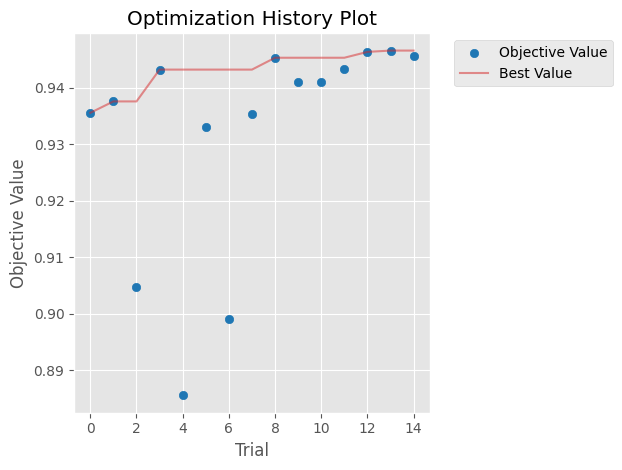

In [7]:
import optuna.visualization.matplotlib as optuna_mpl
import matplotlib.pyplot as plt

optuna_mpl.plot_optimization_history(study)
plt.show()

The Optuna optimization converged on the 6th out of 20 attempts, confirming that the chosen search space was sufficiently targeted.

In [8]:
print("Meilleurs paramètres :", study.best_params)
print("Meilleure AUC        :", study.best_value)

Meilleurs paramètres : {'max_depth': 8, 'learning_rate': 0.0613777844726878, 'subsample': 0.7991269891509903, 'colsample_bytree': 0.7840018562413902, 'min_child_weight': 11, 'reg_alpha': 4.663020914282953, 'reg_lambda': 0.005700488783027412}
Meilleure AUC        : 0.9466281585942763


In [9]:
with open('best_params.pkl', 'wb') as f:
    pickle.dump(study.best_params, f)

In [7]:
best_params = study.best_params.copy()

best_params.update({
    'n_estimators':          1000,
    'scale_pos_weight':      len(y[y==0]) / len(y[y==1]),
    'tree_method':           'hist',
    'eval_metric':           'auc',
    'early_stopping_rounds': 50,
    'random_state':          42,
    'n_jobs':                -1,
})

print("Final parameters used :")
for k, v in best_params.items():
    print(f"  {k}: {v}")

Final parameters used :
  max_depth: 9
  learning_rate: 0.06281104665673783
  subsample: 0.669339133197266
  colsample_bytree: 0.6431542166020361
  min_child_weight: 4
  reg_alpha: 0.001490492267892824
  reg_lambda: 0.0018251135583301588
  n_estimators: 1000
  scale_pos_weight: 27.579586700866283
  tree_method: hist
  eval_metric: auc
  early_stopping_rounds: 50
  random_state: 42
  n_jobs: -1


In [8]:
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof    = np.zeros(len(X))
scores = []

for fold, (idx_train, idx_val) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[idx_train], X.iloc[idx_val]
    y_tr, y_val = y.iloc[idx_train], y.iloc[idx_val]

    model = XGBClassifier(**best_params)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=100
    )

    oof[idx_val] = model.predict_proba(X_val)[:, 1]
    scores.append(roc_auc_score(y_val, oof[idx_val]))
    print(f"Fold {fold+1} AUC : {scores[-1]:.4f}")

print(f"\nAUC moyenne    : {np.mean(scores):.4f}")
print(f"AUC OOF totale : {roc_auc_score(y, oof):.4f}")

[0]	validation_0-auc:0.86242
[100]	validation_0-auc:0.94516
[200]	validation_0-auc:0.95722
[300]	validation_0-auc:0.96210
[400]	validation_0-auc:0.96470
[500]	validation_0-auc:0.96611
[600]	validation_0-auc:0.96701
[700]	validation_0-auc:0.96792
[800]	validation_0-auc:0.96898
[900]	validation_0-auc:0.96947
[999]	validation_0-auc:0.97016
Fold 1 AUC : 0.9702
[0]	validation_0-auc:0.86079
[100]	validation_0-auc:0.94457
[200]	validation_0-auc:0.95753
[300]	validation_0-auc:0.96258
[400]	validation_0-auc:0.96582
[500]	validation_0-auc:0.96727
[600]	validation_0-auc:0.96874
[700]	validation_0-auc:0.96981
[800]	validation_0-auc:0.97058
[900]	validation_0-auc:0.97109
[999]	validation_0-auc:0.97154
Fold 2 AUC : 0.9715
[0]	validation_0-auc:0.86150
[100]	validation_0-auc:0.94226
[200]	validation_0-auc:0.95532
[300]	validation_0-auc:0.96157
[400]	validation_0-auc:0.96419
[500]	validation_0-auc:0.96558
[600]	validation_0-auc:0.96709
[700]	validation_0-auc:0.96819
[800]	validation_0-auc:0.96901
[900]

In [9]:
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof    = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
scores = []

for fold, (idx_train, idx_val) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[idx_train], X.iloc[idx_val]
    y_tr, y_val = y.iloc[idx_train], y.iloc[idx_val]

    model = XGBClassifier(**best_params)

    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)

    oof[idx_val] = model.predict_proba(X_val)[:, 1]
    test_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits

    scores.append(roc_auc_score(y_val, oof[idx_val]))
    print(f"Fold {fold+1} AUC : {scores[-1]:.4f}")

print(f"MeanAUC: {np.mean(scores):.4f}")
print(f"AUC OOF totale : {roc_auc_score(y, oof):.4f}")

[0]	validation_0-auc:0.86242
[100]	validation_0-auc:0.94516
[200]	validation_0-auc:0.95722
[300]	validation_0-auc:0.96210
[400]	validation_0-auc:0.96470
[500]	validation_0-auc:0.96611
[600]	validation_0-auc:0.96701
[700]	validation_0-auc:0.96792
[800]	validation_0-auc:0.96898
[900]	validation_0-auc:0.96947
[999]	validation_0-auc:0.97016
Fold 1 AUC : 0.9702
[0]	validation_0-auc:0.86079
[100]	validation_0-auc:0.94457
[200]	validation_0-auc:0.95753
[300]	validation_0-auc:0.96258
[400]	validation_0-auc:0.96582
[500]	validation_0-auc:0.96727
[600]	validation_0-auc:0.96874
[700]	validation_0-auc:0.96981
[800]	validation_0-auc:0.97058
[900]	validation_0-auc:0.97109
[999]	validation_0-auc:0.97154
Fold 2 AUC : 0.9715
[0]	validation_0-auc:0.86150
[100]	validation_0-auc:0.94226
[200]	validation_0-auc:0.95532
[300]	validation_0-auc:0.96157
[400]	validation_0-auc:0.96419
[500]	validation_0-auc:0.96558
[600]	validation_0-auc:0.96709
[700]	validation_0-auc:0.96819
[800]	validation_0-auc:0.96901
[900]

In [10]:
submission = pd.DataFrame({
    'TransactionID': df_test['TransactionID'],
    'isFraud': test_preds
})
submission.to_csv('submission.csv', index=False)

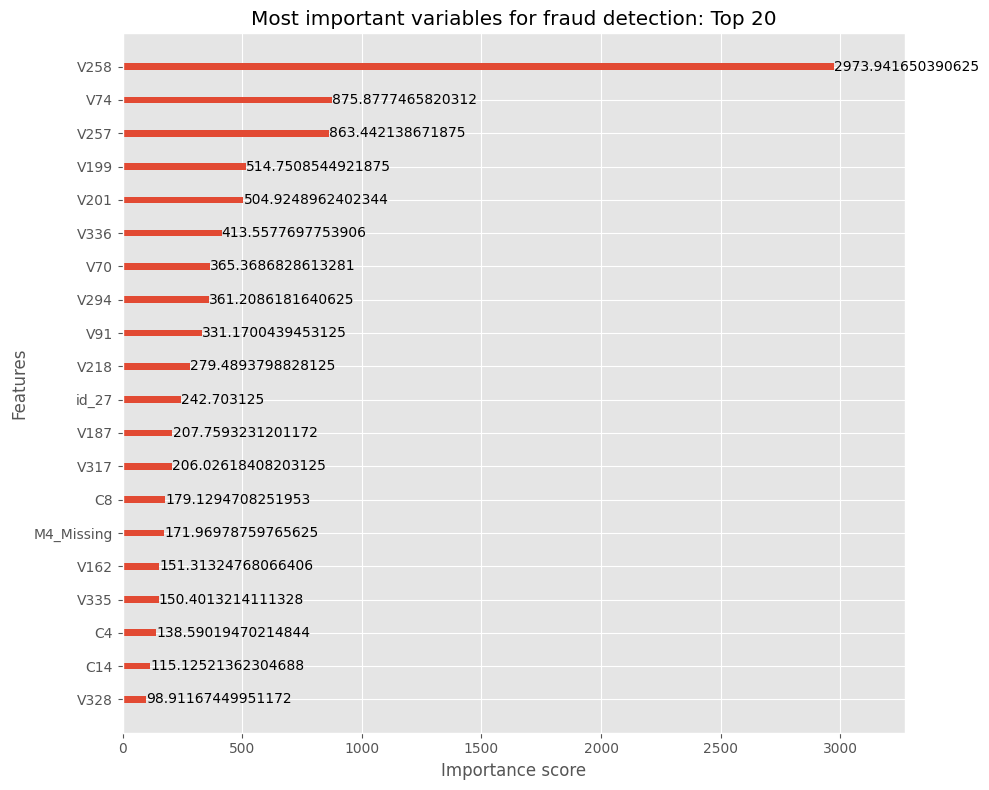

In [14]:
import xgboost


fig, ax = plt.subplots(figsize=(10, 8))
xgboost.plot_importance(model, max_num_features=20, ax=ax, importance_type='gain')
plt.title('Most important variables for fraud detection: Top 20')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()